##Multiclass segmentation metrics(IoU and Dice)

Please upload your image and mask files.


Saving cyclistgrondtruthmask.png to cyclistgrondtruthmask (1).png
Saving originalcyclist.jpg to originalcyclist (2).jpg

Loading image: originalcyclist (2).jpg
Loading mask: cyclistgrondtruthmask (1).png
Using device: cuda

Image shape: (480, 480)
Mask shape: (480, 480)
Classes found in Prediction (by ID): [ 0  2 15]
Classes found in Ground Truth (by ID): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


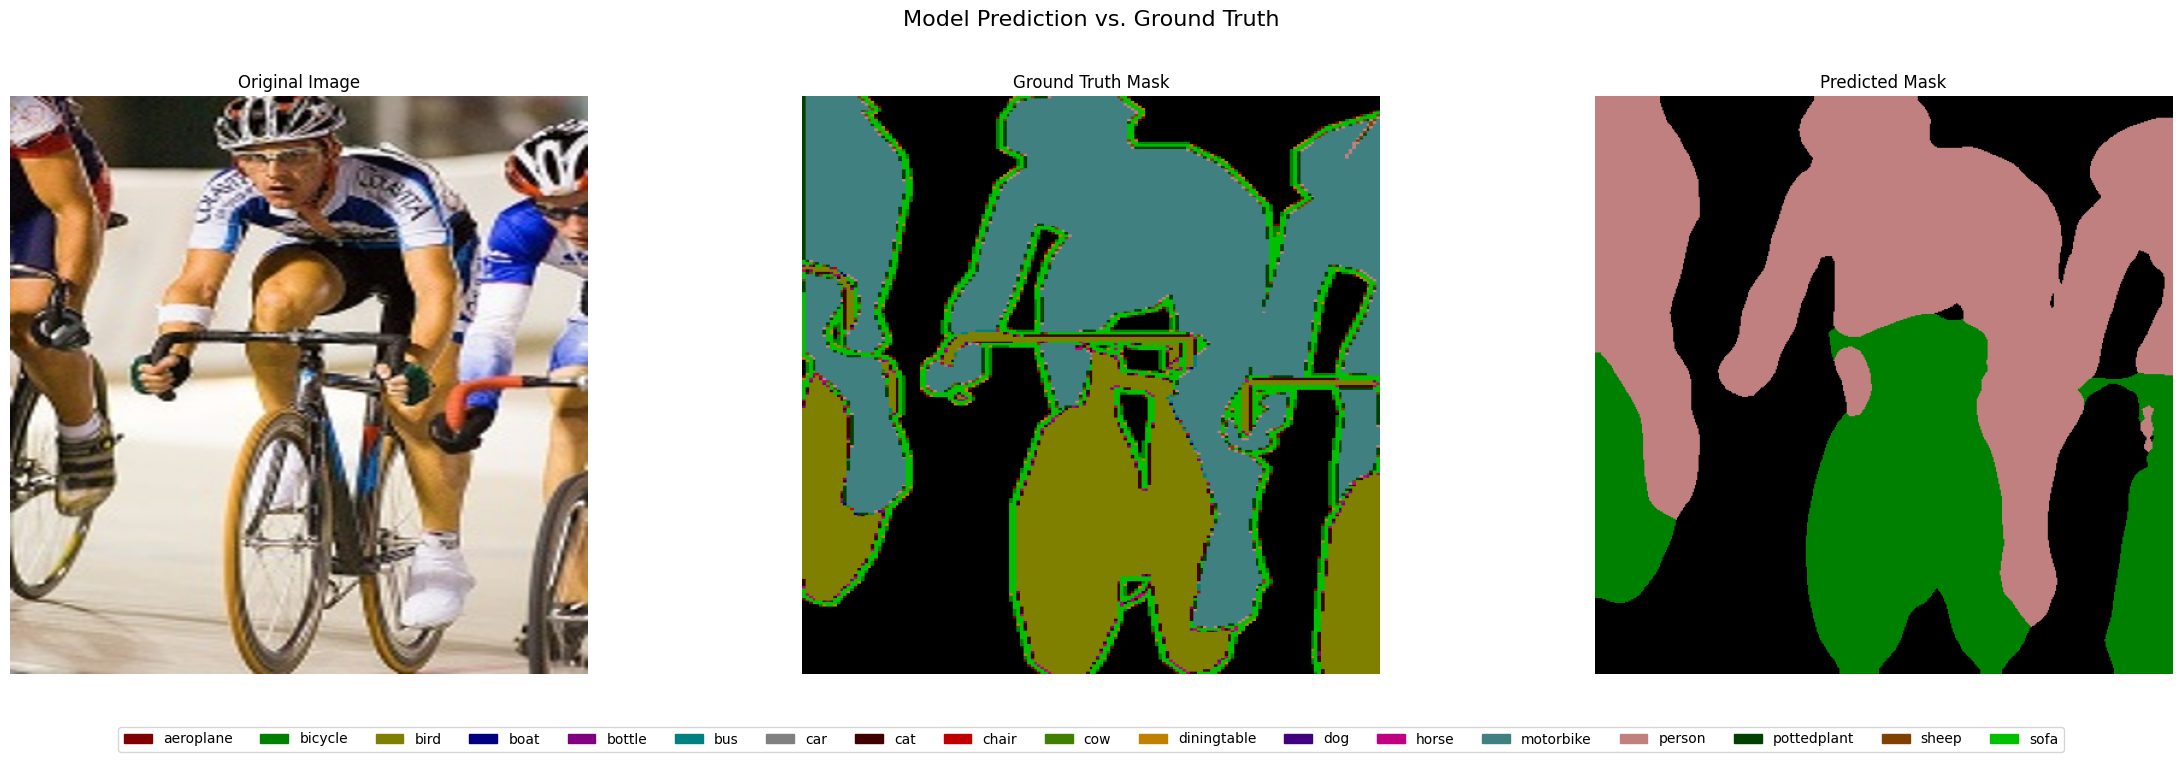


--- Real Metric Calculations ---
Comparing Model Prediction vs. Ground Truth
Class: bicycle         | IoU: 0.0077 | Dice: 0.0153
Class: person          | IoU: 0.0108 | Dice: 0.0214
---------------------------------
Mean IoU (mIoU) [bicycle, person]: 0.0093
Mean Dice [bicycle, person]:       0.0184


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision import models, transforms, datasets
from PIL import Image
import requests
from io import BytesIO

# --- 1. File Upload ---
# This section assumes you are in a Google Colab or similar environment.
try:
    from google.colab import files
    print("Please upload your image and mask files.")
    uploaded = files.upload()

    # Find the uploaded file names
    image_filename = None
    mask_filename = None
    for fn in uploaded.keys():
        if fn.endswith('.jpg') or fn.endswith('.jpeg'):
            image_filename = fn
        elif fn.endswith('.png'):
            mask_filename = fn

    if image_filename is None or mask_filename is None:
        raise RuntimeError("Please upload one .jpg image and one .png mask.")

    print(f"\nLoading image: {image_filename}")
    print(f"Loading mask: {mask_filename}")

    original_img_pil = Image.open(image_filename).convert("RGB")
    gt_mask_pil = Image.open(mask_filename)

except ImportError:
    print("Not in Colab. Please place '2007_000129.jpg' and '2007_000129.png' in the same directory.")
    # Manually specify filenames if not in Colab
    image_filename = "2007_000129.jpg"
    mask_filename = "2007_000129.png"
    try:
        original_img_pil = Image.open(image_filename).convert("RGB")
        gt_mask_pil = Image.open(mask_filename)
    except FileNotFoundError:
        print("---!! ERROR: Files not found. Please upload them or place them in the directory. !!---")
        raise


# --- 2. Model and Image Setup ---

# ✅ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ✅ Pretrained DeepLabV3 (COCO)
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = models.segmentation.deeplabv3_resnet50(weights=weights).to(device).eval()

# ✅ Preprocessing
image_preprocess = transforms.Compose([
    transforms.Resize((480, 480)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mask_preprocess = transforms.Compose([
    transforms.Resize((480, 480), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor() # Converts PIL image to tensor, preserving original values
])

# Resize original image for consistent plotting
original_img_resized = original_img_pil.resize((480, 480))


# --- 3. COCO/PASCAL Classes and Color Map ---
CLASS_NAMES = [
    '__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
num_classes = len(CLASS_NAMES)

def get_colormap():
    return np.array([
        [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
        [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0],
        [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128],
        [64, 128, 128], [192, 128, 128], [0, 64, 0], [128, 64, 0],
        [0, 192, 0], [128, 192, 0], [0, 64, 128]
    ], dtype=np.uint8)

color_map = get_colormap()

# --- 4. Run Inference and Process Masks ---

# Run model inference
tensor = image_preprocess(original_img_pil).unsqueeze(0).to(device)
with torch.no_grad():
    output = model(tensor)['out']
predicted_mask = output.argmax(1).squeeze().cpu().numpy()

# Process Ground Truth Mask
gt_tensor = mask_preprocess(gt_mask_pil)
ground_truth_mask = gt_tensor.squeeze().numpy().astype(np.uint8)
ground_truth_mask[ground_truth_mask == 255] = 0 # Convert PASCAL "void" class to background

print(f"\nImage shape: {original_img_resized.size}")
print(f"Mask shape: {predicted_mask.shape}")
print(f"Classes found in Prediction (by ID): {np.unique(predicted_mask)}")
print(f"Classes found in Ground Truth (by ID): {np.unique(ground_truth_mask)}")


# --- 5. Function to Convert Mask to RGB ---
def colorize_mask(mask, color_map):
    h, w = mask.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    mask = mask.astype(int)
    for class_id, color in enumerate(color_map):
        pixels_to_color = (mask == class_id)
        rgb_mask[pixels_to_color] = color
    return rgb_mask

# --- 6. Generate and Display Masks ---
pred_rgb = colorize_mask(predicted_mask, color_map)
gt_rgb = colorize_mask(ground_truth_mask, color_map)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle("Model Prediction vs. Ground Truth", fontsize=16, y=1.02)

ax1.imshow(original_img_resized)
ax1.set_title("Original Image")
ax1.axis('off')

ax2.imshow(gt_rgb)
ax2.set_title("Ground Truth Mask")
ax2.axis('off')

ax3.imshow(pred_rgb)
ax3.set_title("Predicted Mask")
ax3.axis('off')

# --- Add a clear legend ---
present_class_ids = np.unique(np.concatenate((predicted_mask, ground_truth_mask)))
patches = [
    mpatches.Patch(color=np.array(color_map[i])/255., label=CLASS_NAMES[i])
    for i in present_class_ids if CLASS_NAMES[i] != '__background__'
]
fig.legend(handles=patches, loc='lower center', ncol=max(1, len(patches)), bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# --- 7. Metric Calculation ---

def calculate_iou(pred_mask, gt_mask, class_id):
    pred_class = (pred_mask == class_id)
    gt_class = (gt_mask == class_id)
    intersection = np.logical_and(pred_class, gt_class).sum()
    union = np.logical_or(pred_class, gt_class).sum()
    if union == 0:
        return np.nan
    return intersection / union

def calculate_dice(pred_mask, gt_mask, class_id):
    pred_class = (pred_mask == class_id)
    gt_class = (gt_mask == class_id)
    intersection = np.logical_and(pred_class, gt_class).sum()
    if (pred_class.sum() + gt_class.sum()) == 0:
        return np.nan
    return (2. * intersection) / (pred_class.sum() + gt_class.sum())

# --- Calculate and Print REAL Metrics ---
iou_scores = []
dice_scores = []

print("\n--- Real Metric Calculations ---")
print("Comparing Model Prediction vs. Ground Truth")

# Filter for specific classes
target_classes = ['bicycle', 'person']
target_class_ids = [CLASS_NAMES.index(name) for name in target_classes]

all_present_ids = np.unique(np.concatenate((predicted_mask, ground_truth_mask)))

for class_id in all_present_ids:
    if class_id not in target_class_ids: continue # Skip classes not in target_classes

    iou = calculate_iou(predicted_mask, ground_truth_mask, class_id)
    dice = calculate_dice(predicted_mask, ground_truth_mask, class_id)

    if not np.isnan(iou):
        class_name = CLASS_NAMES[class_id]
        print(f"Class: {class_name:<15} | IoU: {iou:.4f} | Dice: {dice:.4f}")
        iou_scores.append(iou)
        dice_scores.append(dice)

# Calculate and print mean scores
mean_iou = np.nanmean(iou_scores)
mean_dice = np.nanmean(dice_scores)

print("---------------------------------")
print(f"Mean IoU (mIoU) [{', '.join(target_classes)}]: {mean_iou:.4f}")
print(f"Mean Dice [{', '.join(target_classes)}]:       {mean_dice:.4f}")